In [306]:
import pandas as pd
import altair as alt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt



In [307]:
# spotify dataset from GitHub
username = "datagus"
repository = "ASDA2025"
directory = "datasets/homework_week11/6.3.3_spotify_5000_songs.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
df = pd.read_csv(github_url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5235 entries, 0 to 5234
Data columns (total 17 columns):
 #   Column                                                                                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                                                                                             --------------  -----  
 0   name                                                                                                                                                                               5235 non-null   object 
 1   artist                                                                                                                                                                             5235 non-null   object 
 2   danceability                                            

In [308]:
df.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
0,Se Eu Quiser Falar Com Deus,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR1tcGFq7
1,Saudade De Bahia,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwSJwTm5Zq
2,"Canta Canta, Minha Gente",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwnkn5PJYs
3,Mulher Eu Sei,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67WsAxryPFs
4,Rosa Morena,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkIPPdp0eA


In [309]:
# clustering features
audio_features = [
    "danceability","energy","loudness","speechiness","acousticness",
    "instrumentalness","liveness","valence","tempo","duration_ms"
]
df.columns = df.columns.str.strip()

# Create a dataframe with only these features
X = df[audio_features].copy()
X = X.dropna(axis=0)


In [310]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,5.235000e+03,5.235000e+03,5.235000e+03,5.235000e+03,5235.000000,5.235000e+03,5.235000e+03,5.235000e+03,5.235000e+03,5.235000e+03
mean,4.343337e-17,1.737335e-16,-2.823169e-16,1.085834e-17,0.000000,6.515005e-17,7.600839e-17,-1.303001e-16,-2.497419e-16,1.194418e-16
std,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00
min,-2.336953e+00,-2.266902e+00,-8.048919e+00,-1.168457e+00,-0.814841,-6.942831e-01,-1.240690e+00,-1.597402e+00,-4.156077e+00,-1.586426e+00
25%,-9.196533e-01,-6.054811e-01,-3.175759e-01,-6.205996e-01,-0.807958,-6.942803e-01,-6.215280e-01,-8.916011e-01,-7.893166e-01,-4.270767e-01
50%,1.352948e-01,2.928655e-01,3.177660e-01,-3.845994e-01,-0.546826,-6.892109e-01,-4.039847e-01,-9.577442e-02,1.605395e-02,-1.713918e-01
75%,8.187177e-01,8.304861e-01,6.472732e-01,2.173415e-01,0.773862,1.040503e+00,3.457031e-01,8.404923e-01,5.355225e-01,1.755554e-01
max,2.098416e+00,1.201618e+00,1.696803e+00,1.172727e+01,1.983299,1.963204e+00,5.365934e+00,1.949608e+00,3.335065e+00,2.630788e+01


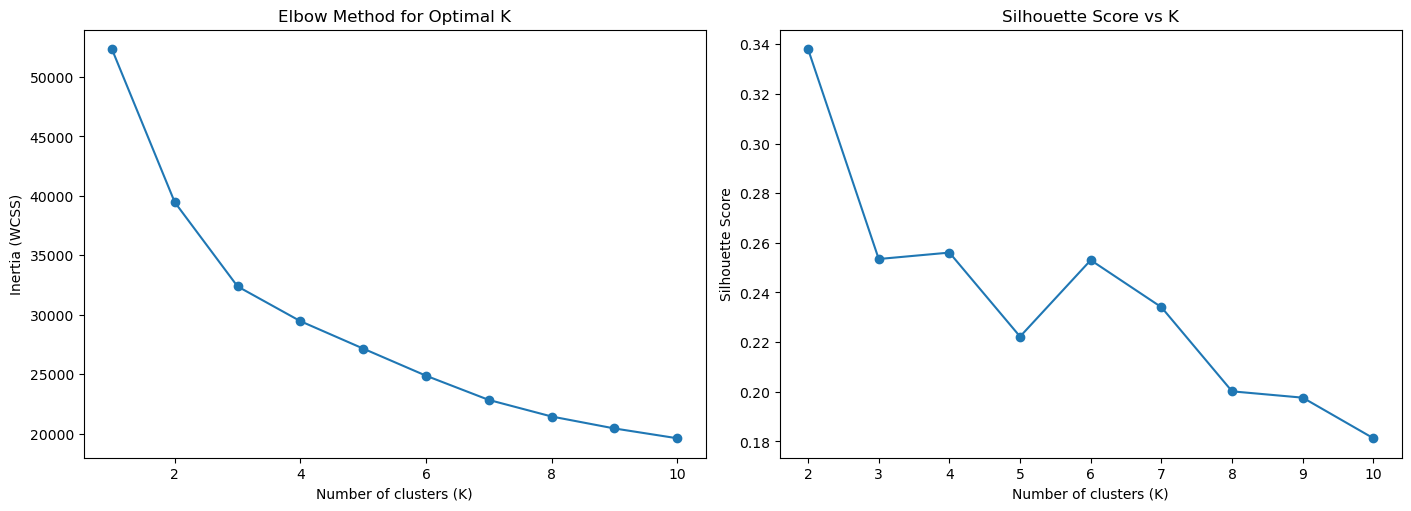

In [311]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)


silhouette_scores = []

for k in range(2, 11):  # silhouette requires k ≥ 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# ---- Elbow plot ----
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method for Optimal K')

# ---- Silhouette plot ----
axes[1].plot(range(2, 11), silhouette_scores, marker='o')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')

plt.show()


In [312]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++", 
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_
df["cluster"] = labels

In [313]:
k = centroids.shape[0]
distances = pd.DataFrame(index=X_scaled.index)

for i in range(k):
    diff = X_scaled.values - centroids[i]
    dist = np.sqrt(np.sum(diff**2, axis=1))
    distances[f"centroid_{i}"] = dist

distances.head()

,centroid_0,centroid_1,centroid_2,centroid_3
0,6.141167,5.870855,6.390953,6.395717
1,4.040901,1.576376,3.739663,3.854949
2,6.455128,4.553758,2.499724,5.523739
3,3.205410,3.685508,4.957344,5.177313
4,2.341316,3.558704,5.010852,4.908108


In [314]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results
X_pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=X_scaled.index
)
# Attach cluster labels
X_pca_df["cluster"] = df["cluster"]

# Display variance explained
variance_explained = pca.explained_variance_ratio_
print(f"""
**PCA Results:**
- PC1 explains {variance_explained[0]:.2%} of variance
- PC2 explains {variance_explained[1]:.2%} of variance
- Total variance explained: {variance_explained.sum():.2%}
""")


**PCA Results:**
- PC1 explains 33.00% of variance
- PC2 explains 18.92% of variance
- Total variance explained: 51.92%



In [315]:
# Transform centroids to PCA space
centroids_pca = pca.transform(centroids) 

centroids_df = pd.DataFrame(centroids_pca, columns=["PC1", "PC2"])
centroids_df["cluster"] = centroids_df.index.astype(str)


c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [316]:
alt.data_transformers.disable_max_rows()
plot_df = X_pca_df.copy()
plot_df["cluster"] = df["cluster"].astype(str)

# trimming extreme PCA outliers for visualization only
lower_q = X_pca_df["PC1"].quantile(0.01)
upper_q = X_pca_df["PC1"].quantile(0.99)

plot_df = X_pca_df[
    (X_pca_df["PC1"] >= lower_q) &
    (X_pca_df["PC1"] <= upper_q)
].copy()


points = alt.Chart(plot_df).mark_circle(size=30, opacity=0.6).encode(
    x=alt.X('PC1:Q', title=f'PC1 ({variance_explained[0]:.1%} variance)'),
    y=alt.Y('PC2:Q', title=f'PC2 ({variance_explained[1]:.1%} variance)'),
    color=alt.Color('cluster:N', title='Cluster', scale=alt.Scale(scheme='category10')),
    tooltip=['PC1:Q', 'PC2:Q', 'cluster:N']
)

centroids_plot = alt.Chart(centroids_df).mark_point(
    shape='cross',
    size=300,
    filled=True,
    strokeWidth=3
).encode(
    x='PC1:Q',
    y='PC2:Q',
    color=alt.Color('cluster:N', scale=alt.Scale(scheme='category10')),
    tooltip=['PC1:Q', 'PC2:Q', 'cluster:N']
)

chart = (points + centroids_plot).properties(
    title='K-Means Clusters',
    width=600,
    height=500
)

chart

alt.LayerChart(...)

In [317]:
# check mean for each cluster rounded to 2
df.groupby("cluster")[audio_features].mean().round(2)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.35,0.15,-20.31,0.05,0.91,0.60,0.15,0.21,105.25,314341.45
1,0.65,0.68,-7.02,0.06,0.24,0.04,0.18,0.61,120.75,222416.49
2,0.68,0.74,-6.10,0.27,0.18,0.02,0.22,0.58,123.56,229528.08
3,0.29,0.90,-7.63,0.10,0.02,0.53,0.21,0.23,122.15,259819.34


In [318]:
df["cluster"].value_counts()

cluster
1    2615
3    1327
0     880
2     413
Name: count, dtype: int64

In [319]:
# Get PCA loadings (how original features contribute to PCs)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create DataFrame with loadings
loadings_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=X_scaled.columns
)

# Scale loadings for visualization
scale_factor = 3
loadings_df_scaled = loadings_df * scale_factor

# Add feature names
loadings_df_scaled['feature'] = loadings_df_scaled.index

# trimming extreme PCA outliers for visualization only
lower_q = X_pca_df["PC1"].quantile(0.01)
upper_q = X_pca_df["PC1"].quantile(0.99)

plot_df = X_pca_df[
    (X_pca_df["PC1"] >= lower_q) &
    (X_pca_df["PC1"] <= upper_q)
].copy()

# Create arrows for loadings
loadings_chart_data = []
for feature in loadings_df_scaled.index:
    loadings_chart_data.append({
        'feature': feature,
        'x': 0,
        'y': 0,
        'x2': loadings_df_scaled.loc[feature, 'PC1'],
        'y2': loadings_df_scaled.loc[feature, 'PC2']
    })

loadings_chart_df = pd.DataFrame(loadings_chart_data)

# Create the biplot with current iteration clusters
base_points = alt.Chart(plot_df).mark_circle(size=20, opacity=0.3).encode(
    x=alt.X('PC1:Q', title=f'PC1 ({variance_explained[0]:.1%} variance)'),
    y=alt.Y('PC2:Q', title=f'PC2 ({variance_explained[1]:.1%} variance)'),
    color=alt.Color('cluster:N', title='Cluster', scale=alt.Scale(scheme='category10'))
)

# Create arrows for loadings
arrows = alt.Chart(loadings_chart_df).mark_rule(strokeWidth=2, color='red').encode(
    x='x:Q',
    y='y:Q',
    x2='x2:Q',
    y2='y2:Q'
)

# Create text labels for loadings
labels = alt.Chart(loadings_chart_df).mark_text(
    align='center',
    baseline='middle',
    dx=0,
    dy=-10,
    fontSize=11,
    fontWeight='bold'
).encode(
    x='x2:Q',
    y='y2:Q',
    text='feature:N'
)

# Combine all layers
biplot = (base_points + arrows + labels).properties(
    title=f'Biplot - K-Means',
    width=700,
    height=600
)

biplot

alt.LayerChart(...)

In [320]:
linkage_matrix = linkage(
    X_scaled,
    method="ward"
)

linkage_matrix_df = pd.DataFrame(
    linkage_matrix,
    columns=["cluster_1", "cluster_2", "distance", "n_observations"]
)

linkage_matrix_df.head(10)

,cluster_1,cluster_2,distance,n_observations
0,0.0,174.0,0.0,2.0
1,10.0,2494.0,0.0,2.0
2,1672.0,2237.0,0.0,2.0
3,745.0,1746.0,0.0,2.0
4,1198.0,3164.0,0.0,2.0
5,494.0,1306.0,0.0,2.0
6,623.0,1614.0,0.0,2.0
7,628.0,1740.0,0.0,2.0
8,568.0,1739.0,0.0,2.0
9,774.0,1732.0,0.0,2.0


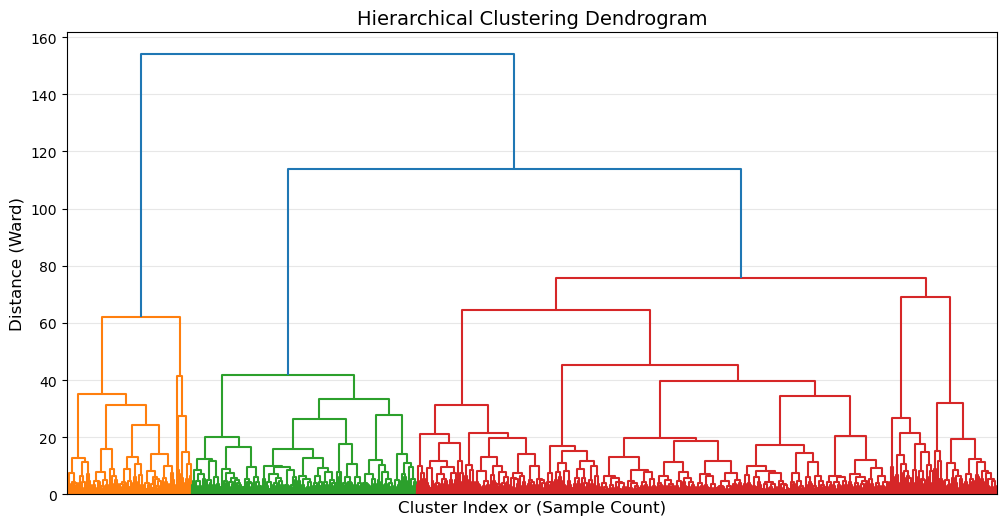

In [321]:
# Create the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    #truncate_mode="lastp",  # important for readability
    #p=30,
    show_contracted=True,
    no_labels=True
)


plt.title('Hierarchical Clustering Dendrogram', fontsize=14)
plt.xlabel('Cluster Index or (Sample Count)', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.gca();

In [322]:
cut_height = 72
clusters_at_72 = fcluster(linkage_matrix, t=cut_height, criterion="distance")
print("Number of clusters at cut=72:", len(np.unique(clusters_at_72)))



Number of clusters at cut=72: 4


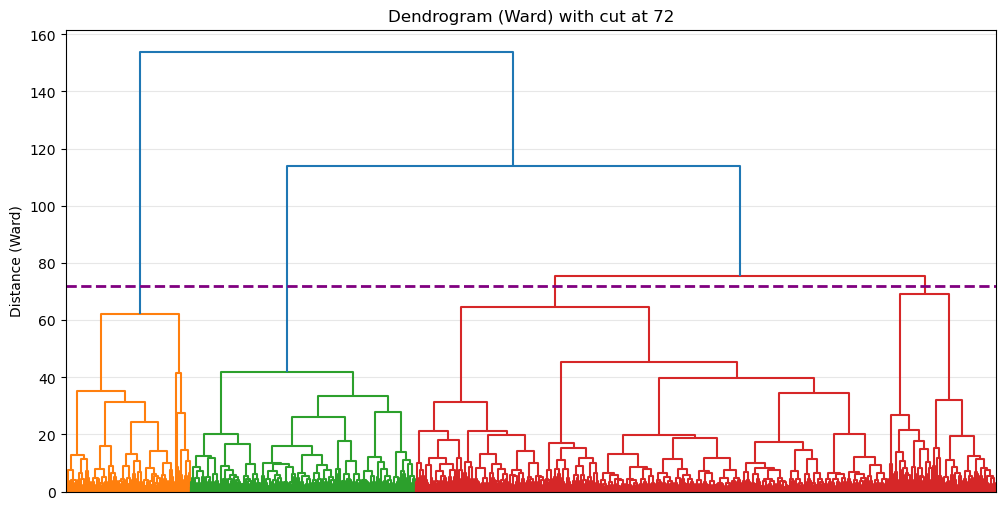

In [323]:
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, show_contracted=True, no_labels=True)
plt.axhline(y=72, color="purple", linestyle="--", linewidth=2)
plt.title("Dendrogram (Ward) with cut at 72")
plt.ylabel("Distance (Ward)")
plt.grid(True, alpha=0.3)
plt.show()

In [324]:
X_clusters_height_72 = X_scaled.copy()  
X_clusters_height_72["h_cluster"] = clusters_at_72

X_clusters_height_72.head(10)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,h_cluster
0,0.681116,-1.368556,-0.604187,-0.178099,1.134867,-0.694125,5.285610,-0.495488,-0.292147,0.061214,4
1,1.066401,-0.882963,-0.525544,-0.682409,-0.205206,-0.694278,-0.524470,0.898109,0.221160,-0.413244,3
2,1.566355,0.265117,-0.271661,3.706071,0.457807,-0.694112,-0.410678,1.661526,-0.875994,-0.705236,4
3,0.896692,-2.092782,-1.394432,-0.506814,1.654602,-0.694174,1.343056,0.289535,-0.417262,-0.454831,3
4,0.649009,-1.854148,-1.663249,-0.634647,1.758549,-0.693358,-0.544551,-0.149790,0.077701,0.190008,1
5,-0.199537,-1.760498,-1.296724,-0.256766,1.800690,-0.278798,-0.524470,-0.074168,0.845894,0.010882,1
6,0.759090,-1.548919,-0.712063,-0.402861,1.890590,0.422671,-0.491002,0.865699,-0.881840,-0.757441,3
7,-0.025241,0.275523,-0.219550,4.296071,1.140486,-0.694132,3.264131,1.593107,-0.775629,0.456045,4
8,0.846238,-0.373090,-0.335847,-0.606552,0.303292,-0.489238,-0.216563,0.710855,1.796229,-0.323582,3
9,0.754503,0.729899,0.217198,-0.631838,0.985970,0.271585,-0.310274,0.332748,-0.655555,-0.492392,3


In [343]:
# trimming extreme PCA outliers for visualization only
lower_q = X_pca_df["PC1"].quantile(0.01)
upper_q = X_pca_df["PC1"].quantile(0.99)

plot_df_height_72 = X_pca_df.copy()
plot_df_height_72["h_cluster"] = pd.Series(
    clusters_at_72, index=X_pca_df.index
).astype(str)

plot_df_height_72_trim = plot_df_height_72[
    (plot_df_height_72["PC1"] >= lower_q) &
    (plot_df_height_72["PC1"] <= upper_q)
].copy()

chart_height_72 = alt.Chart(plot_df_height_72_trim).mark_circle(size=30, opacity=0.6).encode(
    x=alt.X("PC1:Q", title=f"PC1 ({variance_explained[0]:.1%} variance)"),
    y=alt.Y("PC2:Q", title=f"PC2 ({variance_explained[1]:.1%} variance)"),
    color=alt.Color("h_cluster:N", title="Hierarchical Cluster", scale=alt.Scale(scheme="category10")),
    tooltip=["PC1:Q", "PC2:Q", "h_cluster:N"]
).properties(
    title="Hierarchical Clustering – Cut at Height 72",
    width=650,
    height=520
)

chart_height_72

alt.Chart(...)

In [344]:
labels_km = kmeans.fit_predict(X_scaled)
df = df.drop(columns=["cluster"], errors="ignore")
df.loc[X.index, "cluster"] = labels_km

In [345]:
# 1. Check dtype
print(df.loc[X.index, "cluster"].dtype)

# 2. Check unique values
print(df.loc[X.index, "cluster"].unique())

# 3. Check for NaNs
print(df.loc[X.index, "cluster"].isna().sum())

# 4. Check types (should all be int)
print(df.loc[X.index, "cluster"].map(type).value_counts())


float64
[1. 2. 0. 3.]
0
cluster
<class 'float'>    5235
Name: count, dtype: int64


In [346]:
df[audio_features].dtypes


danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
dtype: object

In [347]:
df[audio_features] = df[audio_features].apply(
    pd.to_numeric, errors="coerce"
)

In [348]:
df[audio_features].isna().sum()

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
dtype: int64

In [349]:
df_clean = df.loc[X.index, audio_features + ["cluster"]]


In [350]:
cluster_means = (
    df_clean
    .groupby("cluster")[audio_features]
    .mean()
)

cluster_means.round(2)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0.0,0.35,0.15,-20.31,0.05,0.91,0.60,0.15,0.21,105.25,314341.45
1.0,0.65,0.68,-7.02,0.06,0.24,0.04,0.18,0.61,120.75,222416.49
2.0,0.68,0.74,-6.10,0.27,0.18,0.02,0.22,0.58,123.56,229528.08
3.0,0.29,0.90,-7.63,0.10,0.02,0.53,0.21,0.23,122.15,259819.34


In [351]:
cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()
cluster_z.round(2)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0.0,-0.69,-1.44,-1.49,-0.71,1.46,0.97,-1.32,-0.91,-1.49,1.38
1.0,0.76,0.20,0.48,-0.60,-0.25,-0.83,-0.22,0.94,0.33,-0.82
2.0,0.95,0.37,0.62,1.45,-0.40,-0.89,0.83,0.79,0.66,-0.65
3.0,-1.02,0.87,0.39,-0.15,-0.81,0.75,0.71,-0.81,0.50,0.08


In [352]:
df.loc[valid_idx, "cluster"] = df.loc[valid_idx, "cluster"].astype(int)

playlist_names = {
    0: "Quiet Hours",
    1: "Feel-Good Grooves",
    2: "Urban Pulse",
    3: "Heavy After Hours"
}

playlist_images = {
    0: "Minimal desk, soft morning light, neutral tones, calm mood",
    1: "Warm sunset golden hour, bright colors, friends smiling",
    2: "City street at night, bold graffiti, energetic crowd, movement",
    3: "Dark concert stage, heavy metal band performing, distorted guitars, smoke, red and black lighting"
}

df.loc[X.index, "playlist_name"] = df.loc[X.index, "cluster"].map(playlist_names)
df.loc[X.index, "image_prompt"] = df.loc[X.index, "cluster"].map(playlist_images)

In [353]:
from sklearn.metrics import pairwise_distances

# Ensure cluster exists for exactly X.index rows and is numeric
df.loc[X.index, "cluster"] = pd.to_numeric(df.loc[X.index, "cluster"], errors="coerce")

# Drop any rows that still have missing clusters (should be none, but safe)
valid_idx = df.loc[X.index, "cluster"].dropna().index

# Recompute D only for valid rows (keeps alignment perfect)
D = pairwise_distances(X_scaled.loc[valid_idx].values, centroids)

assigned = df.loc[valid_idx, "cluster"].astype(int).to_numpy()

dist_to_own = D[np.arange(D.shape[0]), assigned]

df.loc[valid_idx, "dist_to_centroid"] = dist_to_own

In [354]:
ranked = (
    df.loc[valid_idx]
      .sort_values("dist_to_centroid")
)
ranked_unique_artists = (
    ranked
      .groupby(["playlist_name", "artist"], as_index=False)
      .head(1)
)
samples_unique = (
    ranked_unique_artists
      .groupby(["cluster", "playlist_name"], as_index=False)
      .head(5)
      [["cluster", "playlist_name", "name", "artist", "html"]]
      .sort_values(["cluster"])
)
pd.set_option("display.max_colwidth", None)

samples_unique



,cluster,playlist_name,name,artist,html
114,0.0,Quiet Hours,Violão Vadio,Raphael Rabello,https://open.spotify.com/track/5zE2UL4L0EAOl0do6kD3Hp
4595,0.0,Quiet Hours,Saku,Susumu Yokota,https://open.spotify.com/track/78WANNBMEK80nVGTWFGXyg
1954,0.0,Quiet Hours,Before You Go - Piano Version,Flying Fingers,https://open.spotify.com/track/5HOLJ0YEEXbsYBZAetdWie
2509,0.0,Quiet Hours,Young And Foolish,Bill Evans,https://open.spotify.com/track/1WygPWqmNs4s2fxtjmtI3O
1880,0.0,Quiet Hours,The Unforgettable,Dirk Maassen,https://open.spotify.com/track/5n3e2n40UzvjkX9xLW0Dn6
4814,1.0,Feel-Good Grooves,Lass mich nie mehr los - Studio Version,Sportfreunde Stiller,https://open.spotify.com/track/6xhI2HskPudsR3Tp6xaQJN
1283,1.0,Feel-Good Grooves,I Guess That's Why They Call It The Blues,Elton John,https://open.spotify.com/track/23l1kVpqMVREiwU1YAlcr4
5042,1.0,Feel-Good Grooves,Guerrera,DELLAFUENTE,https://open.spotify.com/track/3Q6zROQvMXRtR9NYfDpNWL
2919,1.0,Feel-Good Grooves,Waiting For Love,Avicii,https://open.spotify.com/track/2P4OICZRVAQcYAV2JReRfj
940,1.0,Feel-Good Grooves,I Got You Babe,Sonny & Cher,https://open.spotify.com/track/2SWBfqj1FrS8t8z56G55rP


In [ ]:
 

final_playlists = (
    samples
      .assign(image=lambda d: d["cluster"].map(playlist_images),
              description=lambda d: d["cluster"].map(playlist_desc))
      [["playlist_name","image","description","name","artist","html"]]
      .sort_values(["playlist_name"])
)
pd.set_option("display.max_colwidth", None)
final_playlists


,playlist_name,image,description,name,artist,html
940,Feel-Good Grooves,"Warm sunset golden hour, bright colors, friends smiling","High danceability + high valence → upbeat, feel-good, mainstream-friendly",I Got You Babe,Sonny & Cher,https://open.spotify.com/track/2SWBfqj1FrS8t8z56G55rP
4814,Feel-Good Grooves,"Warm sunset golden hour, bright colors, friends smiling","High danceability + high valence → upbeat, feel-good, mainstream-friendly",Lass mich nie mehr los - Studio Version,Sportfreunde Stiller,https://open.spotify.com/track/6xhI2HskPudsR3Tp6xaQJN
1283,Feel-Good Grooves,"Warm sunset golden hour, bright colors, friends smiling","High danceability + high valence → upbeat, feel-good, mainstream-friendly",I Guess That's Why They Call It The Blues,Elton John,https://open.spotify.com/track/23l1kVpqMVREiwU1YAlcr4
5042,Feel-Good Grooves,"Warm sunset golden hour, bright colors, friends smiling","High danceability + high valence → upbeat, feel-good, mainstream-friendly",Guerrera,DELLAFUENTE,https://open.spotify.com/track/3Q6zROQvMXRtR9NYfDpNWL
2919,Feel-Good Grooves,"Warm sunset golden hour, bright colors, friends smiling","High danceability + high valence → upbeat, feel-good, mainstream-friendly",Waiting For Love,Avicii,https://open.spotify.com/track/2P4OICZRVAQcYAV2JReRfj
4218,Heavy After Hours,"Dark concert stage, heavy metal band performing, distorted guitars, smoke, red and black lighting","High energy + low valence → intense, dark, after-hours heavy",Frozen Soul,Asphyx,https://open.spotify.com/track/7f7XPEn9EdtNvxtvsXy2jQ
3460,Heavy After Hours,"Dark concert stage, heavy metal band performing, distorted guitars, smoke, red and black lighting","High energy + low valence → intense, dark, after-hours heavy",Disembowel,Autopsy,https://open.spotify.com/track/2R7KEJHuuXyxN3Jsf77ayC
3789,Heavy After Hours,"Dark concert stage, heavy metal band performing, distorted guitars, smoke, red and black lighting","High energy + low valence → intense, dark, after-hours heavy",Ridden with Disease,Autopsy,https://open.spotify.com/track/47FRdUpxkjElZ7sL7Ta1sX
3591,Heavy After Hours,"Dark concert stage, heavy metal band performing, distorted guitars, smoke, red and black lighting","High energy + low valence → intense, dark, after-hours heavy",Charred Remains,Autopsy,https://open.spotify.com/track/7ffNiXqlhPTSYyBugb5iqC
3687,Heavy After Hours,"Dark concert stage, heavy metal band performing, distorted guitars, smoke, red and black lighting","High energy + low valence → intense, dark, after-hours heavy",The Secrecies of Horror,Pestilence,https://open.spotify.com/track/2KBbyB4hUOMFSOojcyO4dq
